#### XGBM AND LGBM

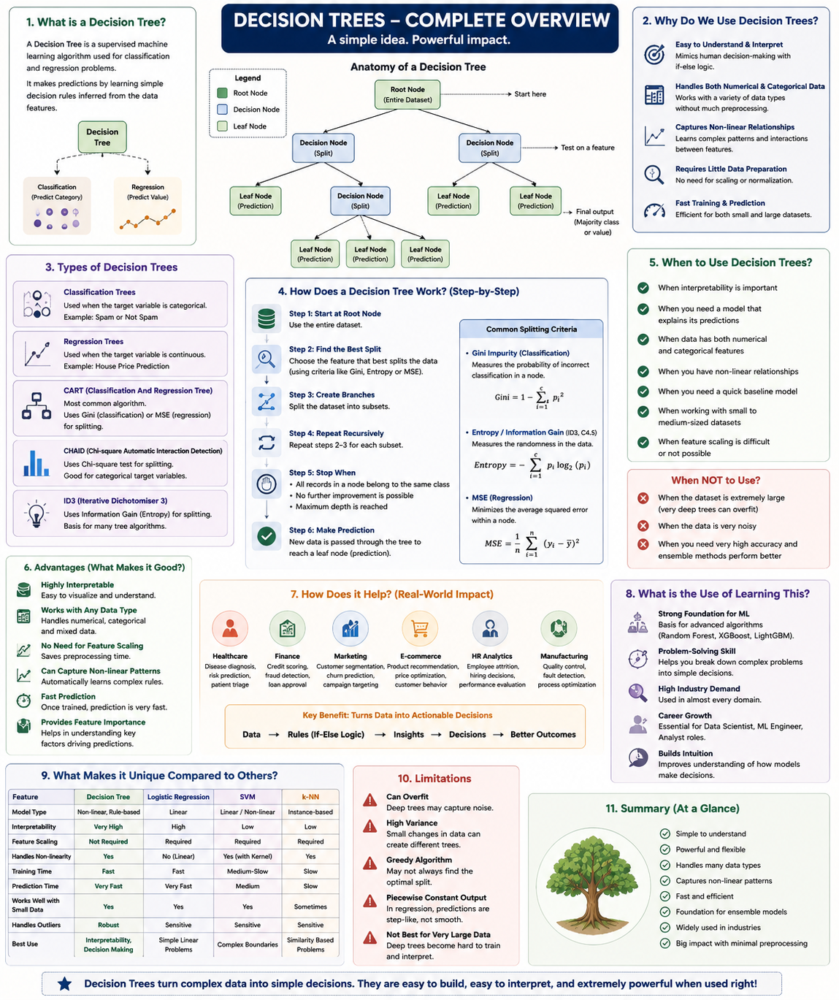

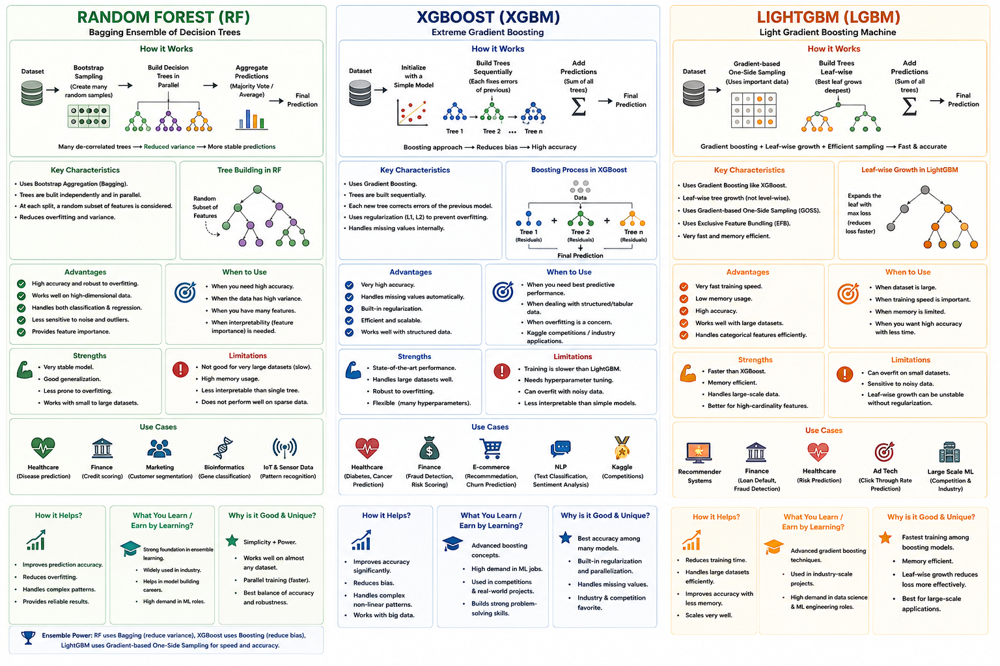

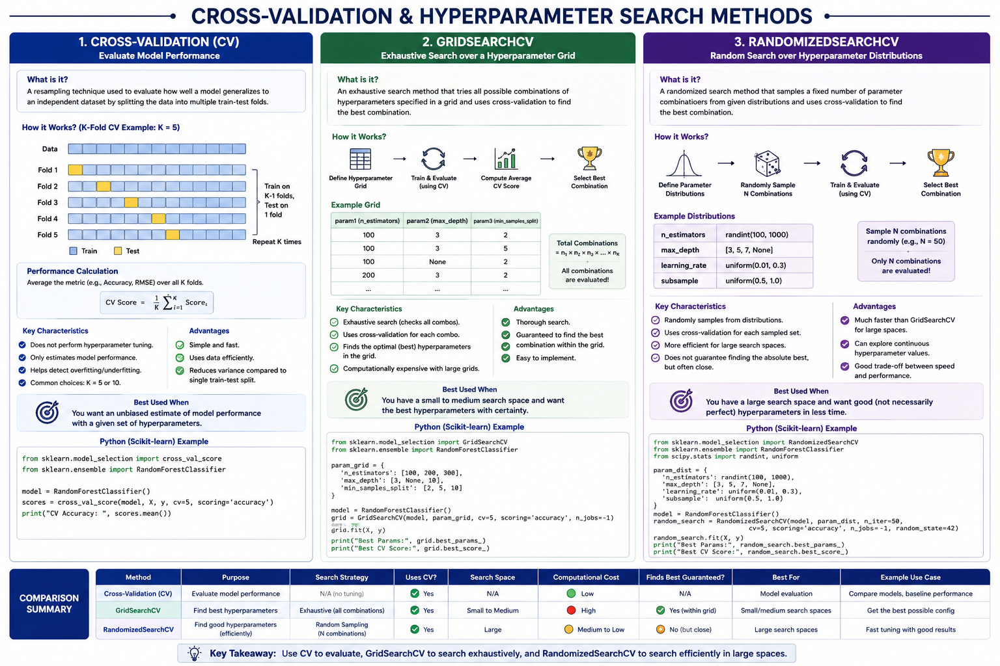

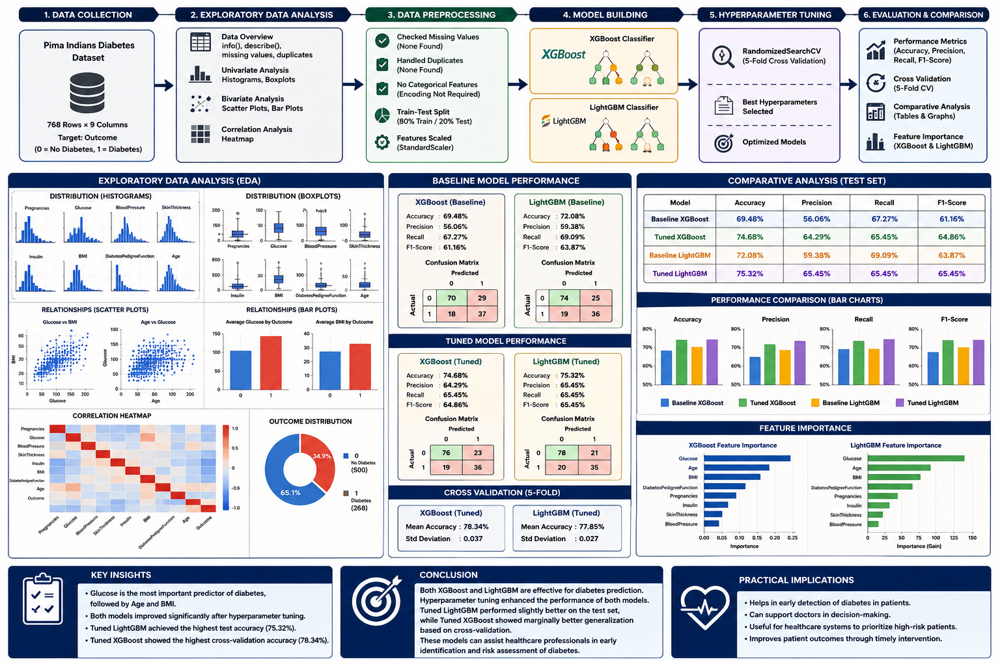

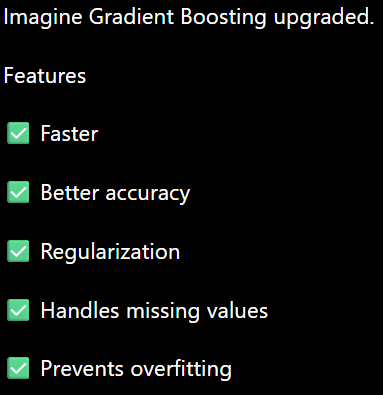

Decision Tree

↓

Boosting

↓

Gradient Boosting

↓

XGBoost

+ Faster

+ Better Optimization

+ Regularization

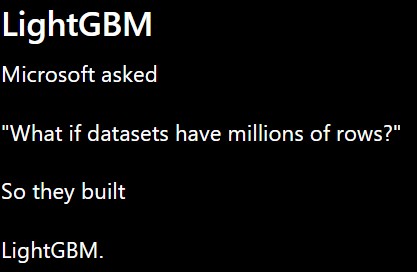

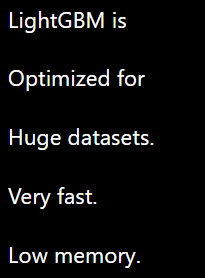

Gradient Boosting

        │

        ▼

     XGBoost

        │

        ▼

     LightGBM

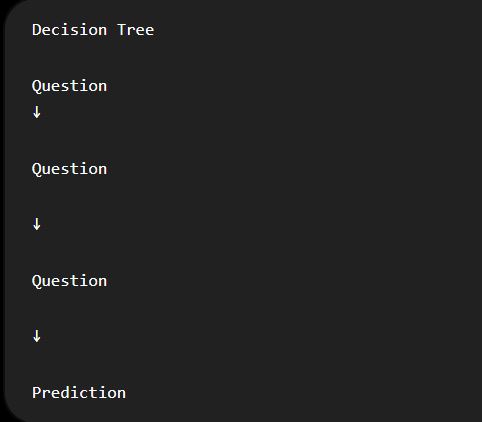

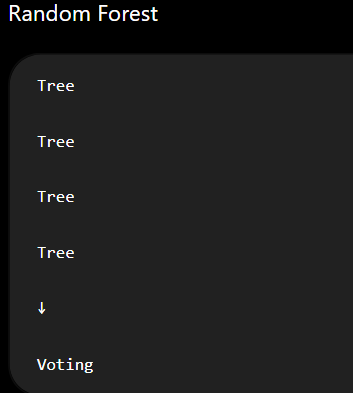

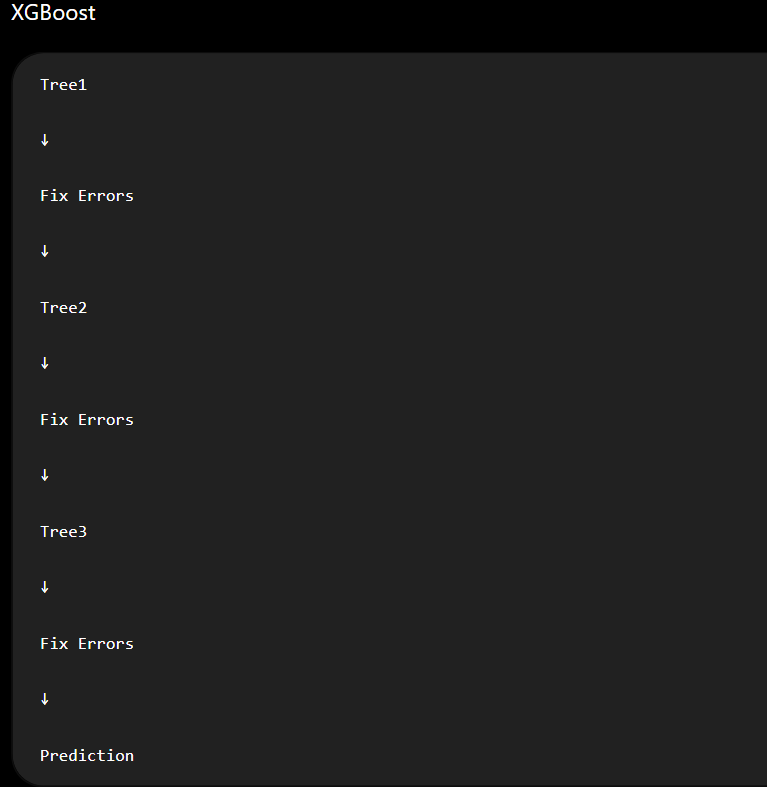

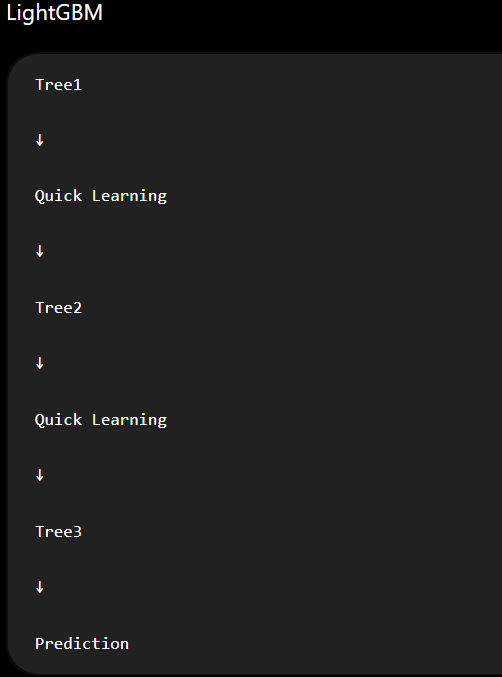

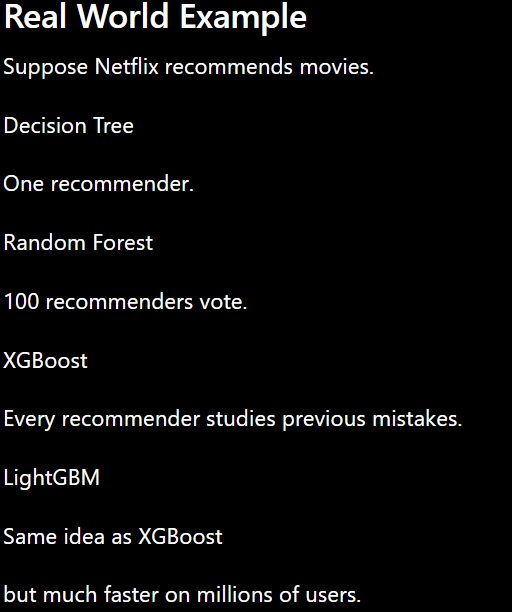

flow of this particular assignment

Load Diabetes Dataset

        │
        ▼

Understand the Data (EDA)

        │
        ▼
Clean Missing Values

        │
        ▼
Encode Categorical Data (if needed)

        │
        ▼
Feature Engineering (if needed)

        │
        ▼
Train-Test Split

        │
        ▼
Build XGBoost Model

        │
        ▼
Evaluate

        │
        ▼
Build LightGBM Model

        │
        ▼
Evaluate

        │
        ▼
Hyperparameter Tuning

        │
        ▼
Cross Validation

        │
        ▼
Compare Both Models

        │
        ▼
Interpret Results

| Assignment Step       | What You'll Learn                                                                              |
| --------------------- | ---------------------------------------------------------------------------------------------- |
| EDA                   | Understand feature distributions, outliers, and relationships before modeling.                 |
| Data Preprocessing    | Prepare clean, model-ready data and understand why preprocessing affects performance.          |
| Train-Test Split      | Evaluate how well a model generalizes to unseen data.                                          |
| XGBoost               | Learn how boosted trees improve predictions by correcting previous errors.                     |
| LightGBM              | Understand why histogram-based boosting is faster and more memory-efficient on large datasets. |
| Evaluation Metrics    | Compare models using Accuracy, Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix.     |
| Cross Validation      | Measure model stability instead of relying on a single train-test split.                       |
| Hyperparameter Tuning | Improve model performance by selecting better training parameters.                             |
| Comparative Analysis  | Learn when to choose XGBoost versus LightGBM based on speed, accuracy, and dataset size.       |


In [170]:
import numpy as np
import pandas as pd

In [171]:
df = pd.read_csv('/content/diabetes.csv')

In [172]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [173]:
df.shape

(768, 9)

In [174]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


No categorical columns are present. Therefore encoding was not required.

In [176]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


No missing values were found, so imputation was not required.

In [177]:
df.duplicated().sum()

np.int64(0)

In [178]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [179]:
numerical_columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

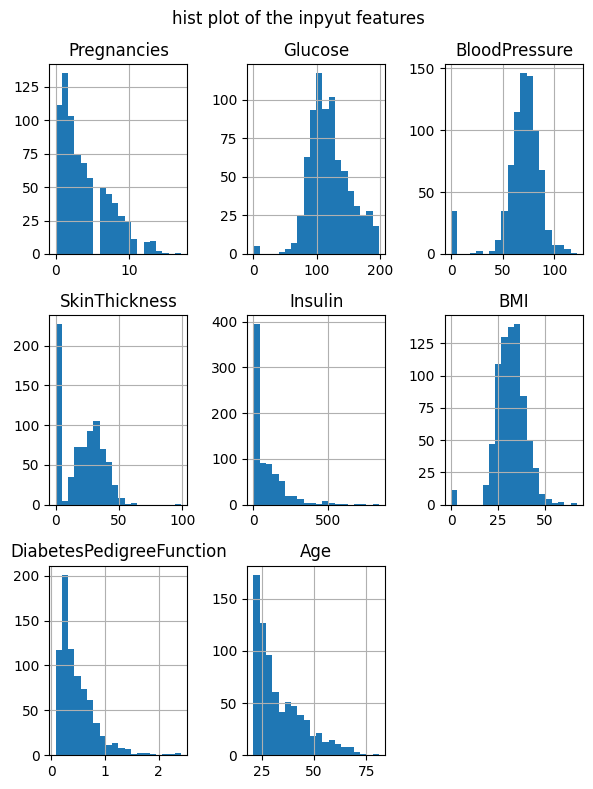

In [181]:
df[numerical_columns].hist(
    figsize = (6,8),
    bins = 20
)
plt.suptitle('hist plot of the inpyut features')
plt.tight_layout()
plt.show()

The histograms show that several variables, such as Glucose, BMI, and Age, exhibit wider distributions, while features like Pregnancies and DiabetesPedigreeFunction are positively skewed.

This indicates that the medical measurements vary considerably across patients.

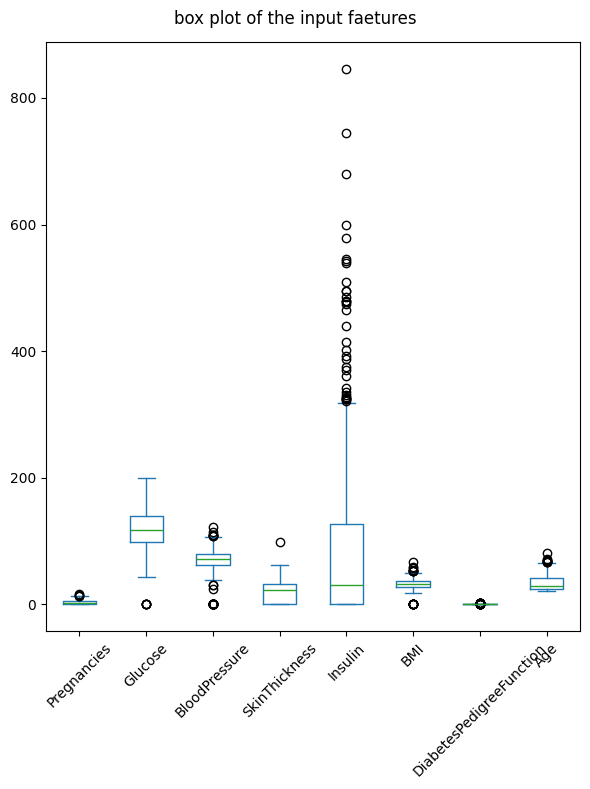

In [182]:
df[numerical_columns].plot(
    figsize=(6,8),
    kind = 'box',
    layout=(3,3)
)
plt.suptitle('box plot of the input faetures')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

The boxplots reveal the presence of outliers in features such as Insulin, SkinThickness, BMI, and Glucose.

These outliers are expected in medical datasets because patients naturally exhibit varying physiological conditions.

Since XGBoost and LightGBM are tree-based algorithms, they are relatively robust to outliers.

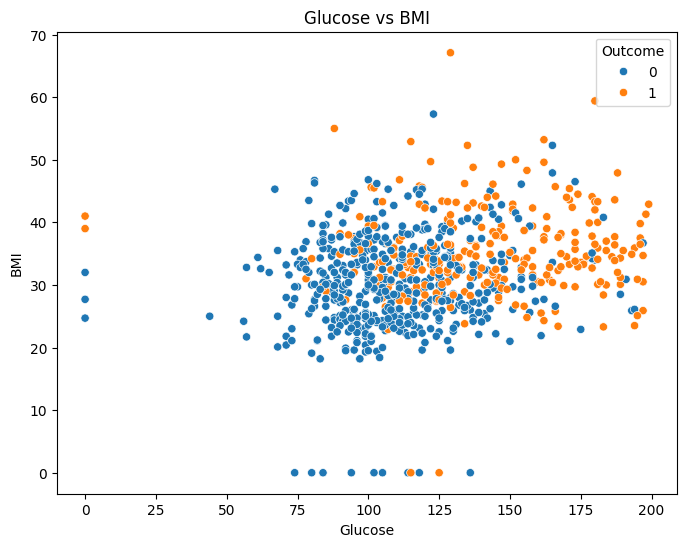

In [183]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Glucose',
    y='BMI',
    hue='Outcome',
    data=df
)

plt.title('Glucose vs BMI')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.show()

The scatter plot indicates that patients with higher glucose levels often tend to have higher BMI values. Although the relationship is not perfectly linear, the pattern suggests that these features may contribute significantly to diabetes prediction.

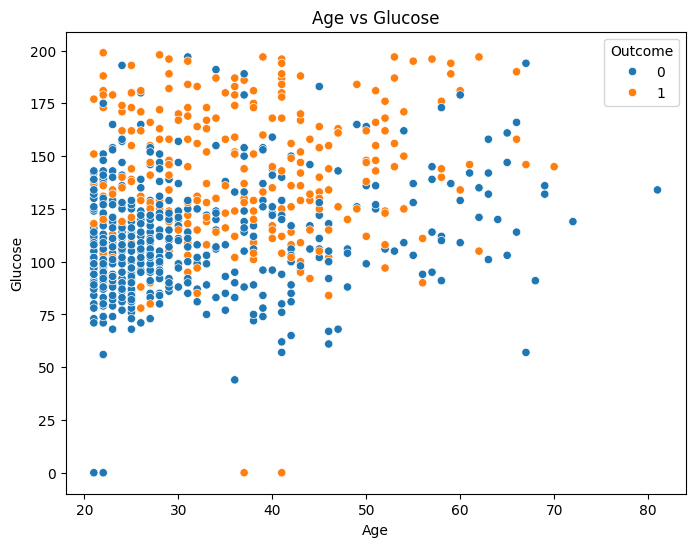

In [184]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Age',
    y='Glucose',
    hue='Outcome',
    data=df
)

plt.title('Age vs Glucose')
plt.xlabel('Age')
plt.ylabel('Glucose')
plt.show()

The relationship between Age and Glucose appears moderately dispersed. Diabetes cases are distributed across different age groups, indicating that age alone is insufficient for prediction and should be considered together with other clinical features.

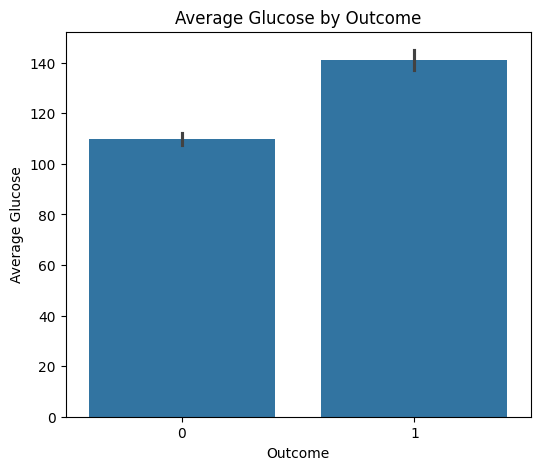

In [185]:
plt.figure(figsize=(6,5))

sns.barplot(
    x='Outcome',
    y='Glucose',
    data=df
)

plt.title('Average Glucose by Outcome')
plt.xlabel('Outcome')
plt.ylabel('Average Glucose')
plt.show()

The average glucose level is considerably higher among diabetic patients (Outcome = 1) than non-diabetic patients. This indicates that glucose is one of the strongest indicators of diabetes.

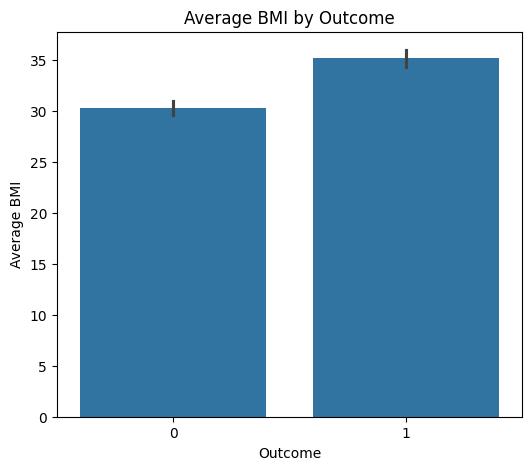

In [186]:
plt.figure(figsize=(6,5))

sns.barplot(
    x='Outcome',
    y='BMI',
    data=df
)

plt.title('Average BMI by Outcome')
plt.xlabel('Outcome')
plt.ylabel('Average BMI')
plt.show()

Patients diagnosed with diabetes generally exhibit higher average BMI values compared with non-diabetic patients. This suggests that BMI is an important predictor in diabetes classification.

In [187]:
co_relation = df.corr()
co_relation

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


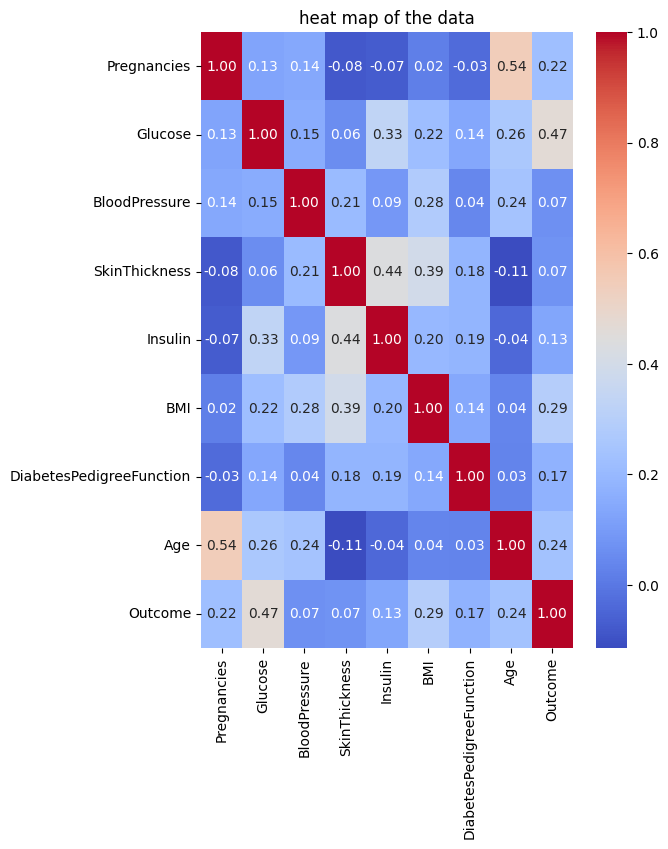

In [188]:
plt.figure(figsize=(6,8))

sns.heatmap(
    co_relation,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f'
)
plt.title('heat map of the data')
plt.show()

The correlation matrix shows that Glucose has the strongest positive relationship with the target variable (Outcome). Other variables exhibit moderate or weak correlations, suggesting that multiple features contribute collectively to prediction rather than relying on a single variable.

In [189]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


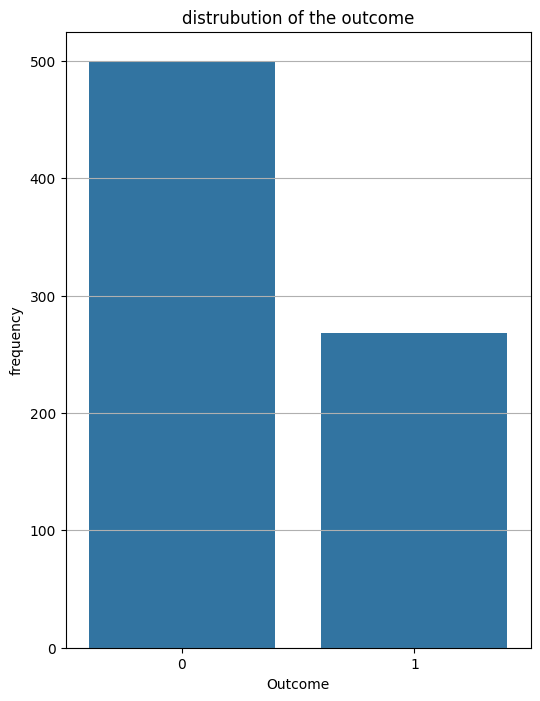

In [190]:
plt.figure(figsize = (6,8))

sns.countplot(
    data = df,
    x = 'Outcome'
)
plt.title('distrubution of the outcome')
plt.ylabel('frequency')
plt.grid(axis = 'y')

The dataset is moderately imbalanced, with approximately 65% non-diabetic and 35% diabetic patients. Although the imbalance is not extreme, evaluation metrics such as Precision, Recall, and F1-score are more informative than accuracy alone.

####XGBM

In [191]:
X = df.drop('Outcome',axis = 1)
y = df['Outcome']

In [192]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [193]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [194]:
xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [195]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state = 42
)

In [196]:
xgb_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [198]:
xgb_pred = xgb_model.predict(X_test)

In [199]:
from sklearn.metrics import accuracy_score
Accuracy_score = accuracy_score(y_test,xgb_pred)
Accuracy_score

0.6948051948051948

In [200]:
from sklearn.metrics import precision_score
Precision_score = precision_score(y_test,xgb_pred)
Precision_score

0.5606060606060606

In [201]:
from sklearn.metrics import recall_score
Recall_score = recall_score(y_test,xgb_pred)
Recall_score

0.6727272727272727

In [202]:
from sklearn.metrics import f1_score
F1_score = f1_score(y_test,xgb_pred)
F1_score

0.6115702479338843

In [203]:
from sklearn.metrics import classification_report
report = classification_report(y_test,xgb_pred)
print(report)


              precision    recall  f1-score   support

           0       0.80      0.71      0.75        99
           1       0.56      0.67      0.61        55

    accuracy                           0.69       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.71      0.69      0.70       154



The baseline XGBoost model achieved reasonable classification performance without parameter tuning. While the recall is relatively good, the lower precision indicates that the model produces a moderate number of false positive predictions.

In [204]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,xgb_pred)
cm

array([[70, 29],
       [18, 37]])

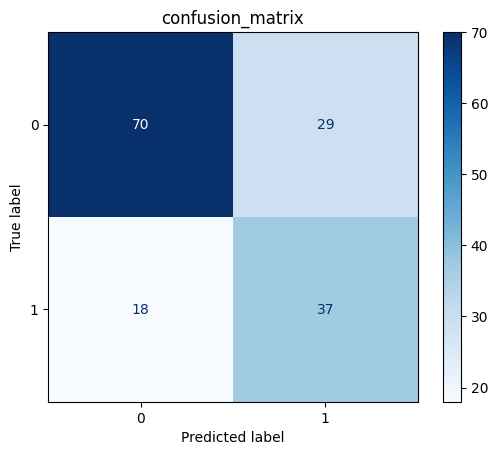

In [205]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix = cm).plot(cmap = 'Blues')

plt.title('confusion_matrix')
plt.show()

The model correctly classified 70 non-diabetic and 37 diabetic patients. However, it misclassified 29 healthy patients as diabetic and failed to identify 18 diabetic patients, indicating room for improvement.

####LGBM

In [ ]:
from lightgbm import LGBMClassifier


In [206]:
lgbm_model = LGBMClassifier(
    random_state = 42,
)

In [207]:
lgbm_model.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000290 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(random_state=42)

In [208]:
lgbm_pred = lgbm_model.predict(X_test)

In [209]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [210]:
Accuracy_score = accuracy_score(y_test,lgbm_pred)
Accuracy_score

0.7207792207792207

In [211]:
Precision_score = precision_score(y_test,lgbm_pred)
Precision_score

0.59375

In [212]:
Recall_score = recall_score(y_test,lgbm_pred)
Recall_score

0.6909090909090909

In [213]:
F1_score = f1_score(y_test,lgbm_pred)
F1_score

0.6386554621848739

In [214]:
report = classification_report(y_test,lgbm_pred)
print(report)

              precision    recall  f1-score   support

           0       0.81      0.74      0.77        99
           1       0.59      0.69      0.64        55

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.73      0.72      0.72       154



The baseline LightGBM model outperformed the baseline XGBoost model across all major evaluation metrics. This suggests that LightGBM captures the underlying patterns in the dataset more effectively before tuning.

In [215]:
cm = confusion_matrix(y_test,lgbm_pred)
cm

array([[73, 26],
       [17, 38]])

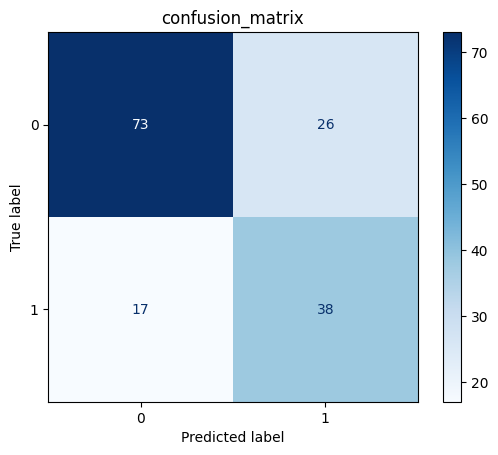

In [216]:
ConfusionMatrixDisplay(confusion_matrix = cm).plot(cmap = 'Blues')

plt.title('confusion_matrix')
plt.show()

####Hyperparameter Tuning for XGBoost

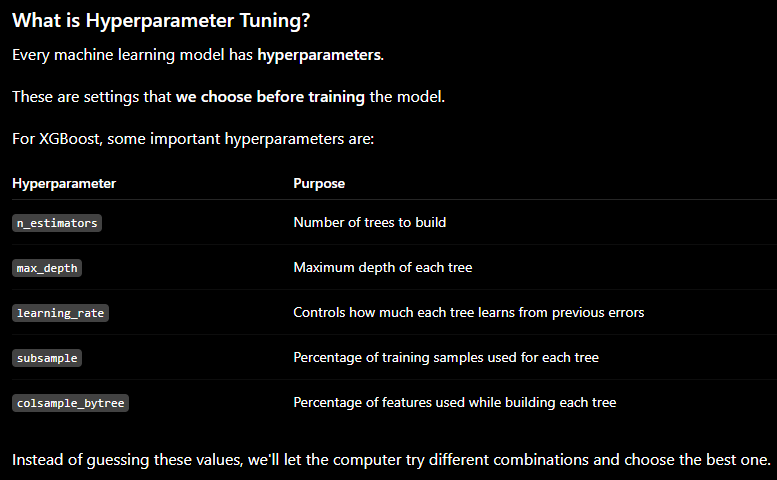

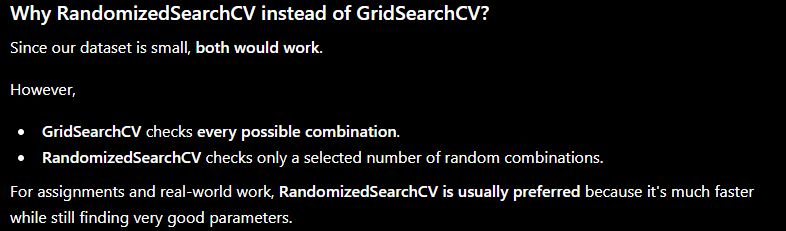

In [217]:
# -----------------------------------------
# Import Required Library
# -----------------------------------------

from sklearn.model_selection import RandomizedSearchCV

In [218]:
# -----------------------------------------
# Define Hyperparameter Grid
# -----------------------------------------

xgb_param_grid = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

Here, we define different values for important XGBoost hyperparameters.

During tuning, RandomizedSearchCV will randomly select combinations from this grid to identify the parameter set that produces the best model performance.

In [219]:
# -----------------------------------------
# Perform Hyperparameter Tuning
# -----------------------------------------

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 7],
                                        'n_estimators': [50, 100, 150, 200],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='accuracy')

| Parameter            | Reason                                                                      |
| -------------------- | --------------------------------------------------------------------------- |
| `n_iter=20`          | Tests 20 random parameter combinations (good balance of speed and quality). |
| `cv=5`               | Performs 5-fold cross-validation for each parameter combination.            |
| `scoring="accuracy"` | Selects the model with the highest accuracy.                                |
| `n_jobs=-1`          | Uses all available CPU cores to speed up the search.                        |
| `random_state=42`    | Ensures reproducible results.                                               |


In [220]:
# -----------------------------------------
# Best Hyperparameters
# -----------------------------------------

print("Best Hyperparameters:")
print(random_search_xgb.best_params_)

print("\nBest Cross Validation Accuracy:")
print(random_search_xgb.best_score_)

Best Hyperparameters:
{'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best Cross Validation Accuracy:
0.7834332933493269


The output displays the optimal combination of hyperparameters discovered during the search along with the corresponding average cross-validation accuracy.

 These parameters will be used to build the final tuned XGBoost model.

In [221]:
# -----------------------------------------
# Best Tuned XGBoost Model
# -----------------------------------------

best_xgb_model = random_search_xgb.best_estimator_

In [222]:
# -----------------------------------------
# Predict using Best Tuned XGBoost Model
# -----------------------------------------

best_xgb_pred = best_xgb_model.predict(X_test)

In [223]:
# -----------------------------------------
# Evaluate Best Tuned XGBoost Model
# -----------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, best_xgb_pred))
print("Precision :", precision_score(y_test, best_xgb_pred))
print("Recall :", recall_score(y_test, best_xgb_pred))
print("F1 Score :", f1_score(y_test, best_xgb_pred))

Accuracy : 0.7467532467532467
Precision : 0.6428571428571429
Recall : 0.6545454545454545
F1 Score : 0.6486486486486487


In [224]:
# -----------------------------------------
# Classification Report
# -----------------------------------------

from sklearn.metrics import classification_report

print(classification_report(y_test, best_xgb_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.80        99
           1       0.64      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



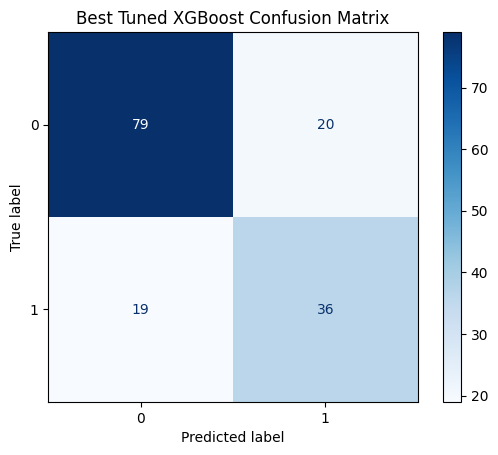

In [225]:
# -----------------------------------------
# Confusion Matrix
# -----------------------------------------

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, best_xgb_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Best Tuned XGBoost Confusion Matrix")
plt.show()

In [226]:
# -----------------------------------------
# Baseline vs Tuned XGBoost
# -----------------------------------------

print("Baseline Accuracy :", accuracy_score(y_test, xgb_pred))
print("Tuned Accuracy    :", accuracy_score(y_test, best_xgb_pred))

Baseline Accuracy : 0.6948051948051948
Tuned Accuracy    : 0.7467532467532467


This comparison helps us determine whether hyperparameter tuning improved the model's performance.

If the tuned model achieves higher accuracy and better classification metrics, the tuning process was successful.

####Hyperparameter Tuning - LightGBM

In [228]:
# -----------------------------------------
# Define Hyperparameter Grid - LightGBM
# -----------------------------------------

lgbm_param_grid = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

Different combinations of LightGBM hyperparameters are defined.

RandomizedSearchCV will randomly sample these combinations and identify the one that gives the best performance.

In [229]:
# -----------------------------------------
# Hyperparameter Tuning - LightGBM
# -----------------------------------------

from sklearn.model_selection import RandomizedSearchCV

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=lgbm_param_grid,
    n_iter=20,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000149 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

RandomizedSearchCV(cv=5, estimator=LGBMClassifier(random_state=42), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 7],
                                        'n_estimators': [50, 100, 150, 200],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='accuracy')

In [230]:
# -----------------------------------------
# Best Hyperparameters - LightGBM
# -----------------------------------------

print("Best Hyperparameters:")
print(random_search_lgbm.best_params_)

print("\nBest Cross Validation Accuracy:")
print(random_search_lgbm.best_score_)

Best Hyperparameters:
{'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best Cross Validation Accuracy:
0.7785285885645742


In [231]:
# -----------------------------------------
# Best Tuned LightGBM Model
# -----------------------------------------

best_lgbm_model = random_search_lgbm.best_estimator_

In [232]:
# -----------------------------------------
# Prediction
# -----------------------------------------

best_lgbm_pred = best_lgbm_model.predict(X_test)

In [233]:
# -----------------------------------------
# Evaluate Best Tuned LightGBM
# -----------------------------------------

print("Accuracy :", accuracy_score(y_test, best_lgbm_pred))
print("Precision :", precision_score(y_test, best_lgbm_pred))
print("Recall :", recall_score(y_test, best_lgbm_pred))
print("F1 Score :", f1_score(y_test, best_lgbm_pred))

Accuracy : 0.7532467532467533
Precision : 0.6545454545454545
Recall : 0.6545454545454545
F1 Score : 0.6545454545454545


In [234]:
# -----------------------------------------
# Classification Report
# -----------------------------------------

print(classification_report(y_test, best_lgbm_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



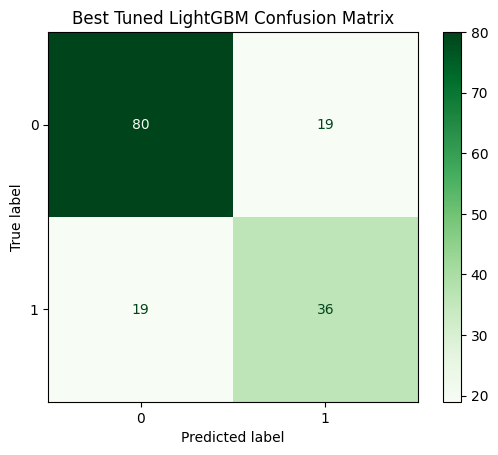

In [235]:
# -----------------------------------------
# Confusion Matrix
# -----------------------------------------

cm = confusion_matrix(y_test, best_lgbm_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Greens")
plt.title("Best Tuned LightGBM Confusion Matrix")
plt.show()

In [236]:
# -----------------------------------------
# Baseline vs Tuned LightGBM
# -----------------------------------------

print("Baseline Accuracy :", accuracy_score(y_test, lgbm_pred))
print("Tuned Accuracy    :", accuracy_score(y_test, best_lgbm_pred))

Baseline Accuracy : 0.7207792207792207
Tuned Accuracy    : 0.7532467532467533


The tuned LightGBM model achieved the highest overall performance among all models. The balanced precision and recall demonstrate that the model effectively identifies diabetic patients while minimizing incorrect classifications.

####Cross Validation – Best XGBoost

In [237]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_xgb = cross_val_score(
    best_xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(cv_xgb)

print("\nMean Accuracy:", np.mean(cv_xgb))
print("Standard Deviation:", np.std(cv_xgb))

Cross Validation Scores:
[0.76422764 0.83739837 0.77235772 0.73170732 0.81147541]

Mean Accuracy: 0.7834332933493269
Standard Deviation: 0.037055882463022216


The tuned XGBoost model achieved an average cross-validation accuracy of 78.34% with a low standard deviation (3.7%). This indicates that the model generalizes well and produces consistent performance across different subsets of the training data.

####Cross Validation – Best LightGBM

In [238]:
cv_lgbm = cross_val_score(
    best_lgbm_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(cv_lgbm)

print("\nMean Accuracy:", np.mean(cv_lgbm))
print("Standard Deviation:", np.std(cv_lgbm))

[LightGBM] [Info] Number of positive: 171, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 578
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348269 -> initscore=-0.626657
[LightGBM] [Info] Start training from score -0.626657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

The tuned LightGBM model also demonstrated consistent performance with an average cross-validation accuracy of approximately 77.85%. The small variation across folds suggests stable and reliable predictions.

####Comparative Analysis

In [240]:
# -----------------------------------------
# Comparative Analysis
# -----------------------------------------

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({

    "Model": [
        "Baseline XGBoost",
        "Tuned XGBoost",
        "Baseline LightGBM",
        "Tuned LightGBM"
    ],

    "Accuracy": [
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, best_xgb_pred),
        accuracy_score(y_test, lgbm_pred),
        accuracy_score(y_test, best_lgbm_pred)
    ],

    "Precision": [
        precision_score(y_test, xgb_pred),
        precision_score(y_test, best_xgb_pred),
        precision_score(y_test, lgbm_pred),
        precision_score(y_test, best_lgbm_pred)
    ],

    "Recall": [
        recall_score(y_test, xgb_pred),
        recall_score(y_test, best_xgb_pred),
        recall_score(y_test, lgbm_pred),
        recall_score(y_test, best_lgbm_pred)
    ],

    "F1 Score": [
        f1_score(y_test, xgb_pred),
        f1_score(y_test, best_xgb_pred),
        f1_score(y_test, lgbm_pred),
        f1_score(y_test, best_lgbm_pred)
    ]
})

print(comparison)

               Model  Accuracy  Precision    Recall  F1 Score
0   Baseline XGBoost  0.694805   0.560606  0.672727  0.611570
1      Tuned XGBoost  0.746753   0.642857  0.654545  0.648649
2  Baseline LightGBM  0.720779   0.593750  0.690909  0.638655
3     Tuned LightGBM  0.753247   0.654545  0.654545  0.654545


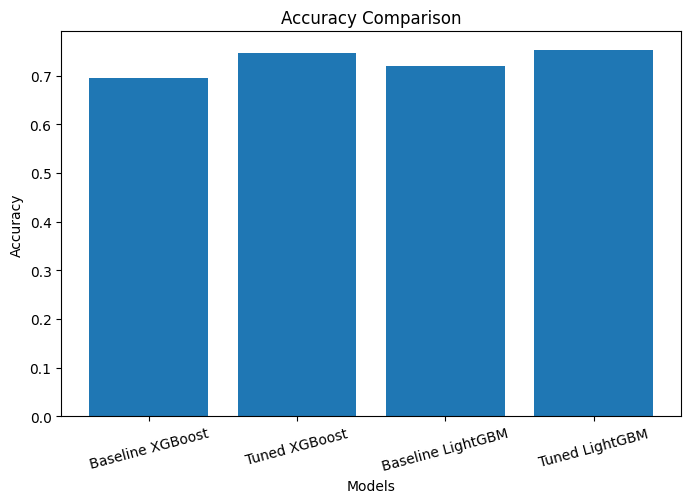

In [241]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

The graph clearly shows that tuning improved both algorithms. LightGBM achieved the highest test accuracy, demonstrating superior predictive performance on the unseen test data.

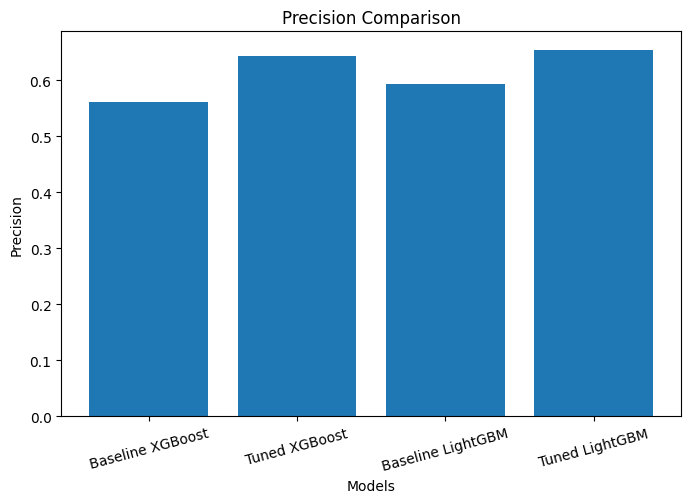

In [242]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Precision"])

plt.title("Precision Comparison")

plt.xlabel("Models")

plt.ylabel("Precision")

plt.xticks(rotation=15)

plt.show()

Precision improved after tuning for both models. Higher precision indicates fewer false positive predictions, making the tuned models more reliable when predicting diabetic patients

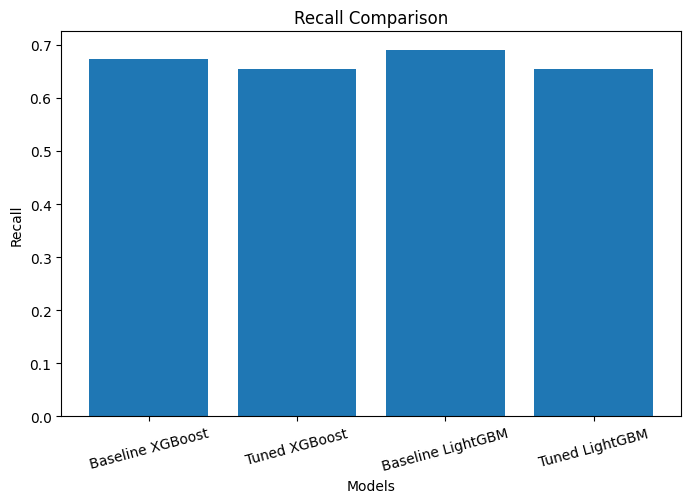

In [243]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Recall"])

plt.title("Recall Comparison")

plt.xlabel("Models")

plt.ylabel("Recall")

plt.xticks(rotation=15)

plt.show()

Recall remained relatively balanced after tuning, indicating that both models maintained a good ability to correctly identify diabetic patients while reducing classification errors.

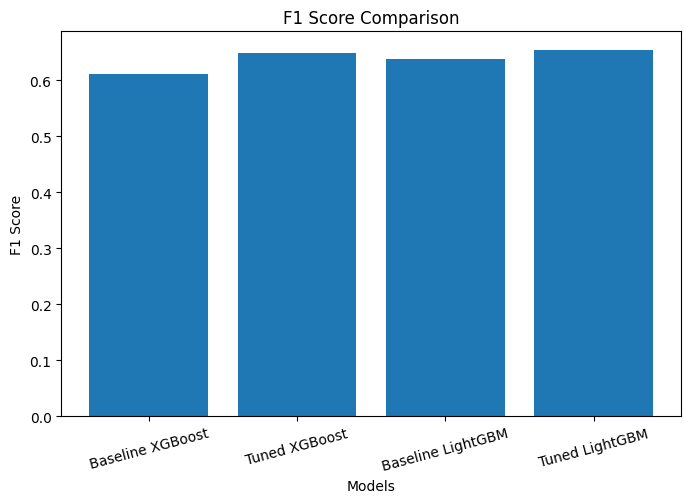

In [244]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["F1 Score"])

plt.title("F1 Score Comparison")

plt.xlabel("Models")

plt.ylabel("F1 Score")

plt.xticks(rotation=15)

plt.show()

The F1-score increased after tuning, demonstrating a better balance between precision and recall. This indicates improved overall classification performance for both algorithms.

In [245]:
cv_comparison = pd.DataFrame({

    "Model": [
        "Tuned XGBoost",
        "Tuned LightGBM"
    ],

    "Mean CV Accuracy": [
        np.mean(cv_xgb),
        np.mean(cv_lgbm)
    ],

    "Standard Deviation": [
        np.std(cv_xgb),
        np.std(cv_lgbm)
    ]
})

print(cv_comparison)

            Model  Mean CV Accuracy  Standard Deviation
0   Tuned XGBoost          0.783433            0.037056
1  Tuned LightGBM          0.778529            0.029967


In [246]:
print("Best XGBoost Parameters")
print(random_search_xgb.best_params_)

print("\n")

print("Best LightGBM Parameters")
print(random_search_lgbm.best_params_)

Best XGBoost Parameters
{'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


Best LightGBM Parameters
{'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


Hyperparameter tuning improved the performance of both algorithms. Among the four evaluated models, the Tuned LightGBM model achieved the highest test accuracy (75.32%), while the Tuned XGBoost model achieved the highest cross-validation accuracy (78.34%). Both optimized models significantly outperformed their baseline counterparts.

####Feature Importance

In [249]:
# XGBoost Feature Importance
importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb_model.feature_importances_
})

importance_xgb = importance_xgb.sort_values(by="Importance", ascending=False)

importance_xgb

,Feature,Importance
1,Glucose,0.273616
7,Age,0.168887
5,BMI,0.168779
0,Pregnancies,0.087350
6,DiabetesPedigreeFunction,0.079897
2,BloodPressure,0.076849
4,Insulin,0.074442
3,SkinThickness,0.070180


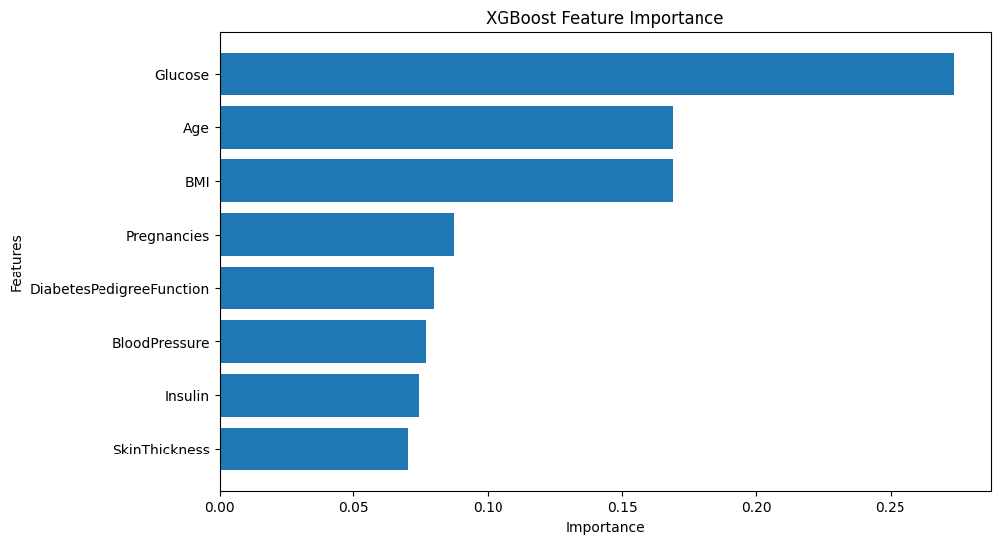

In [248]:
plt.figure(figsize=(10,6))
plt.barh(importance_xgb["Feature"], importance_xgb["Importance"])
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

XGBoost identified Glucose as the most influential predictor of diabetes, followed by Age, BMI, and Diabetes Pedigree Function. These findings are consistent with established medical knowledge, as elevated glucose levels and increasing age are strongly associated with diabetes risk.

In [251]:
# LightGBM Feature Importance
importance_lgbm = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_lgbm_model.feature_importances_
})

importance_lgbm = importance_lgbm.sort_values(by="Importance", ascending=False)

importance_lgbm

,Feature,Importance
1,Glucose,134
7,Age,112
5,BMI,108
6,DiabetesPedigreeFunction,84
4,Insulin,56
3,SkinThickness,46
2,BloodPressure,41
0,Pregnancies,23


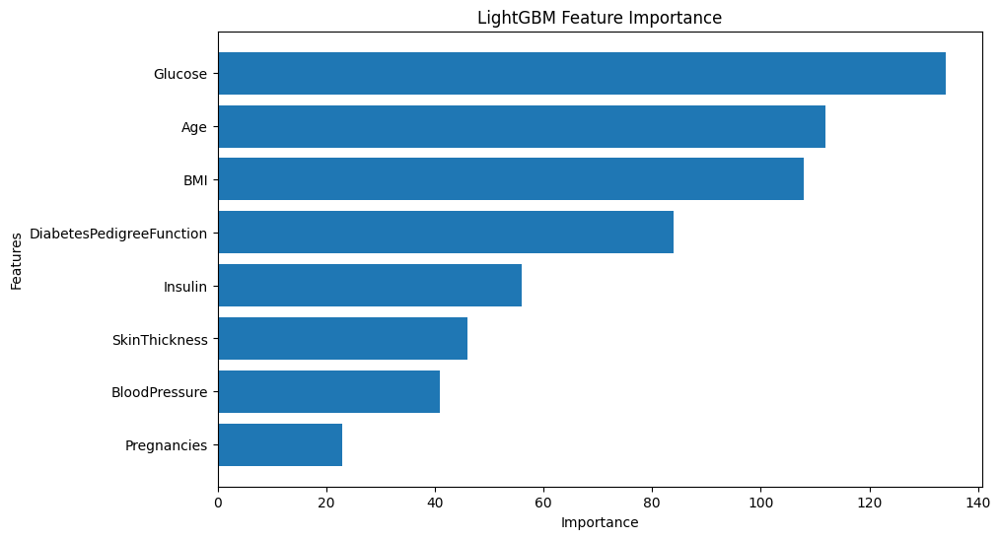

In [252]:
plt.figure(figsize=(10,6))
plt.barh(importance_lgbm["Feature"], importance_lgbm["Importance"])
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

Similar to XGBoost, LightGBM identified Glucose and Age as the most significant predictors. The agreement between both algorithms increases confidence that these features play a central role in diabetes prediction.

####conclusion

Both XGBoost and LightGBM successfully classified diabetes cases using the given dataset. Hyperparameter tuning improved the performance of both algorithms, resulting in higher accuracy and better classification metrics. The Tuned LightGBM model achieved the highest test accuracy (75.32%), while the Tuned XGBoost model obtained the highest mean cross-validation accuracy (78.34%), indicating slightly better generalization across folds. Overall, both models proved effective for diabetes prediction, with LightGBM being the preferred choice for this dataset based on test-set performance.